In [45]:
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
from tensorflow import keras
import os
import cv2
import pandas as pd
from keras.src.layers import Rescaling
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

warnings.filterwarnings('ignore')

Sequential = keras.models.Sequential
Conv2D = keras.layers.Conv2D
Flatten = keras.layers.Flatten
Dropout = keras.layers.Dropout
MaxPooling2D = keras.layers.MaxPooling2D
Dense = keras.layers.Dense
Input = keras.layers.Input
EarlyStopping = keras.callbacks.EarlyStopping
ReduceLROnPlateau = keras.callbacks.ReduceLROnPlateau
Layers = keras.layers
ImageDataGenerator = keras.preprocessing.image.ImageDataGenerator
BatchNormalization = keras.layers.BatchNormalization
CSVLogger = keras.callbacks.CSVLogger

In [18]:
train_path = 'dataset/training/'
test_path = 'dataset/testing/'
PLOT_SAVE_DIR = 'output/plot/v1/'
LOG_DIR = 'output/log/v1/'
MODEL_SAVE_PATH = 'output/model/v1/cnn_model_v1.keras'

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100

train_files = []
train_labels = []

test_files = []
test_labels = []

In [46]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator()

In [47]:
train_ds = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=True
)

test_ds = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=True
)

Found 1998 images belonging to 4 classes.
Found 141 images belonging to 1 classes.


In [48]:
for label in os.listdir(train_path):
    label_path = os.path.join(train_path, label)
    if os.path.isdir(label_path):
        for filename in os.listdir(label_path):
            train_files.append(filename)
            train_labels.append(label)

In [49]:
df_train_files = pd.DataFrame({
    "file": train_files,
    "label": train_labels
})
df_train_files.head()

,file,label
0,traffic_accident_112.jpg,traffic_accident
1,traffic_accident_106.jpg,traffic_accident
2,traffic_accident_18.jpg,traffic_accident
3,traffic_accident_338.jpg,traffic_accident
4,traffic_accident_24.jpg,traffic_accident


In [50]:
class_train_names = df_train_files["label"].unique().tolist()
print(class_train_names)

['traffic_accident', 'blood', 'sexual', 'alcohol']


In [51]:
for label in os.listdir(test_path):
    label_path = os.path.join(test_path, label)
    if os.path.isdir(label_path):
        for filename in os.listdir(label_path):
            test_files.append(filename)
            test_labels.append(label)

In [52]:
df_test_files = pd.DataFrame({
    "file": test_files,
    "label": test_labels
})
df_test_files.head()

,file,label
0,test_14.jpg,unknown
1,test_28.jpg,unknown
2,test_29.jpg,unknown
3,test_15.jpg,unknown
4,test_9.jpg,unknown


In [53]:
class_test_names = df_test_files["label"].unique().tolist()
print(class_test_names)

['unknown']


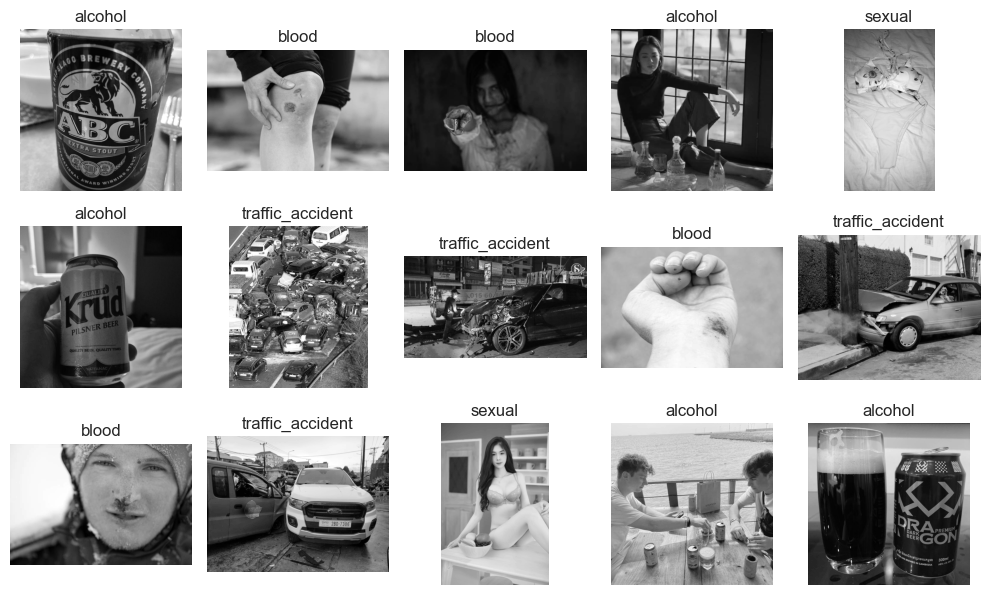

In [54]:
df_train_files = df_train_files.sample(frac=1).reset_index(drop=True)

plt.figure(figsize=(10, 10))

for i in range(15):
    if i >= len(df_train_files):
        break

    file_name = df_train_files.iloc[i]["file"]
    label = df_train_files.iloc[i]["label"]

    image_path = os.path.join(train_path, label, file_name)

    if not os.path.exists(image_path):
        print(f"File not found: {image_path}")
        continue

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"Failed to read image: {image_path}")
        continue

    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

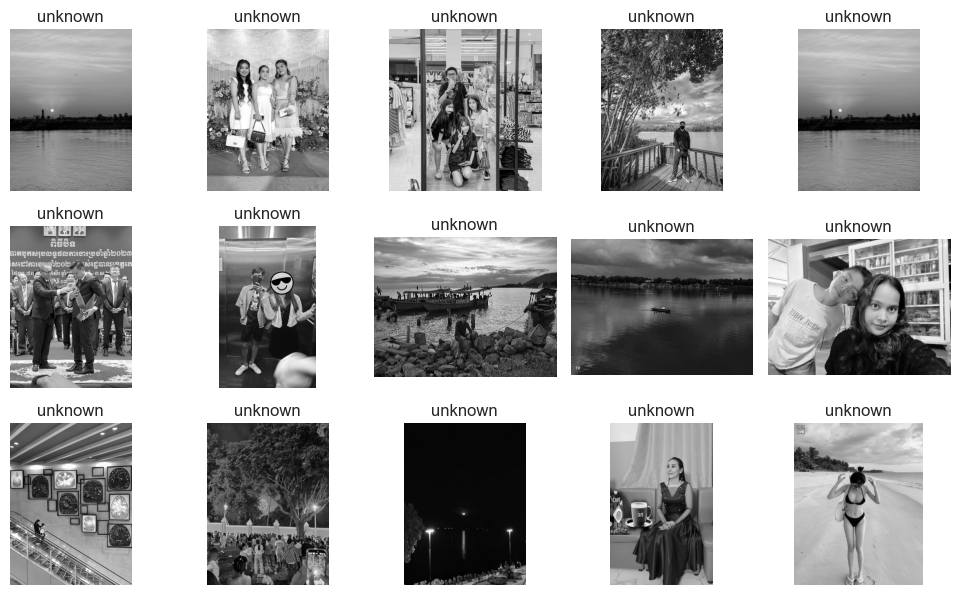

In [55]:
df_test_files = df_test_files.sample(frac=1).reset_index(drop=True)

plt.figure(figsize=(10, 10))

for i in range(15):
    if i >= len(df_train_files):
        break

    file_name = df_test_files.iloc[i]["file"]
    label = df_test_files.iloc[i]["label"]

    image_path = os.path.join(test_path, label, file_name)

    if not os.path.exists(image_path):
        print(f"File not found: {image_path}")
        continue

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"Failed to read image: {image_path}")
        continue

    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [56]:
train_class_counts = {}
for class_name in os.listdir(train_path):
    class_dir = os.path.join(train_path, class_name)
    if os.path.isdir(class_dir):
        num_images = len(os.listdir(class_dir))
        train_class_counts[class_name] = num_images
for class_name, count in train_class_counts.items():
    print(f"{class_name}: {count} images")

traffic_accident: 500 images
blood: 500 images
sexual: 500 images
alcohol: 500 images


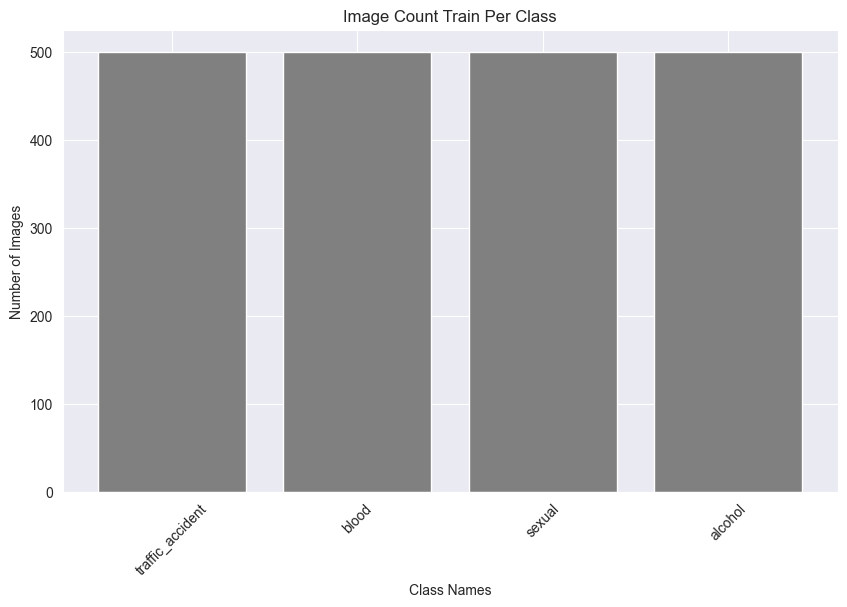

In [57]:
plt.figure(figsize=(10, 6))
plt.bar(train_class_counts.keys(), train_class_counts.values(), color='gray')
plt.title('Image Count Train Per Class')
plt.xlabel('Class Names')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

In [58]:
test_class_counts = {}
for class_name in os.listdir(test_path):
    class_dir = os.path.join(test_path, class_name)
    if os.path.isdir(class_dir):
        num_images = len(os.listdir(class_dir))
        test_class_counts[class_name] = num_images
for class_name, count in test_class_counts.items():
    print(f"{class_name}: {count} images")

unknown: 141 images


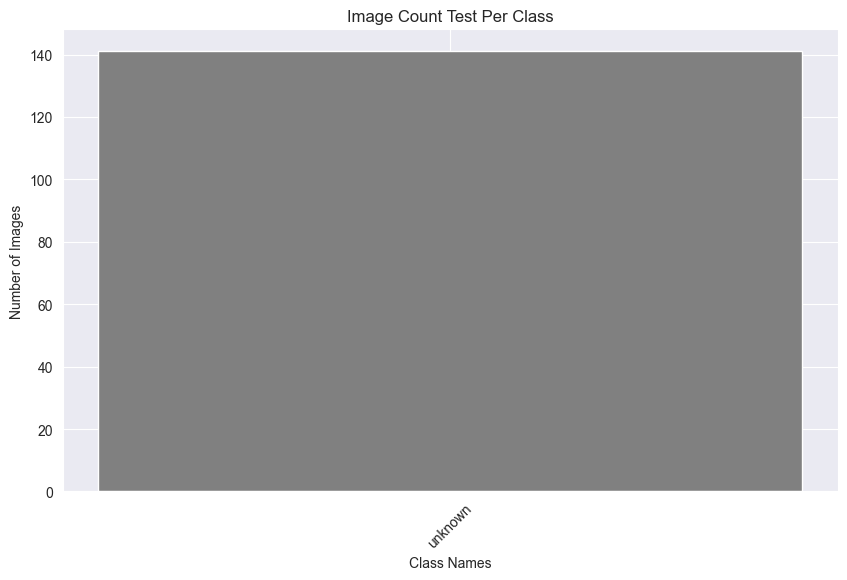

In [59]:
plt.figure(figsize=(10, 6))
plt.bar(test_class_counts.keys(), test_class_counts.values(), color='gray')
plt.title('Image Count Test Per Class')
plt.xlabel('Class Names')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Model architecture
model = Sequential()

# Normalization
model.add(Rescaling(1. / 255, input_shape=(224, 224, 1)))

# Convolutional layers 
model.add(Conv2D(32, kernel_size=(5, 5), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, kernel_size=(5, 5), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

# Flatten and dense layers with Dropout
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.4))

# Output layer
model.add(Dense(units=len(class_train_names), activation='softmax'))

In [ ]:
model.summary()

In [ ]:
# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=5, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    CSVLogger(os.path.join(LOG_DIR, 'training_log_v4.csv'), append=True)
]

# Train model
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Save Model
model.save(MODEL_SAVE_PATH)

In [ ]:
# Evaluation and Report
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test accuracy: {test_accuracy * 100:.2f}%')

In [ ]:
# Evaluate the model on the training dataset
train_loss, train_accuracy = model.evaluate(train_ds)
print(f'Train accuracy: {train_accuracy * 100:.2f}%')

In [ ]:
# Classification Report and Confusion Matrix
y_true = test_ds.classes
y_pred = np.argmax(model.predict(test_ds), axis=1)
print(classification_report(y_true, y_pred, target_names=test_ds.class_indices.keys()))

In [ ]:
# Confusion Matrix Plot
conf_mat = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=test_ds.class_indices.keys(),
            yticklabels=test_ds.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig(os.path.join(PLOT_SAVE_DIR, "confusion_matrix_v4.png"))
plt.show()

In [ ]:
# Plotting Loss and Accuracy
def plot_metrics(history, metric, val_metric, title, y_label, save_path):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history[metric], label="Training")
    plt.plot(history.history[val_metric], label="Validation")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, format="png", dpi=300)
    plt.show()

In [ ]:
plot_metrics(history, 'loss', 'val_loss', "Training and Validation Loss", "Loss",
             os.path.join(PLOT_SAVE_DIR, "training_validation_loss_v1.png"))
plot_metrics(history, 'accuracy', 'val_accuracy', "Training and Validation Accuracy", "Accuracy",
             os.path.join(PLOT_SAVE_DIR, "training_validation_accuracy_v1.png"))

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the true labels for ROC curve (one-hot encoding)
y_true_bin = label_binarize(y_true, classes=list(range(len(test_ds.class_indices))))

# Get model probabilities
y_pred_prob = model.predict(test_ds)

# Plot ROC curve for each class
plt.figure(figsize=(12, 8))
for i, class_name in enumerate(test_ds.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()